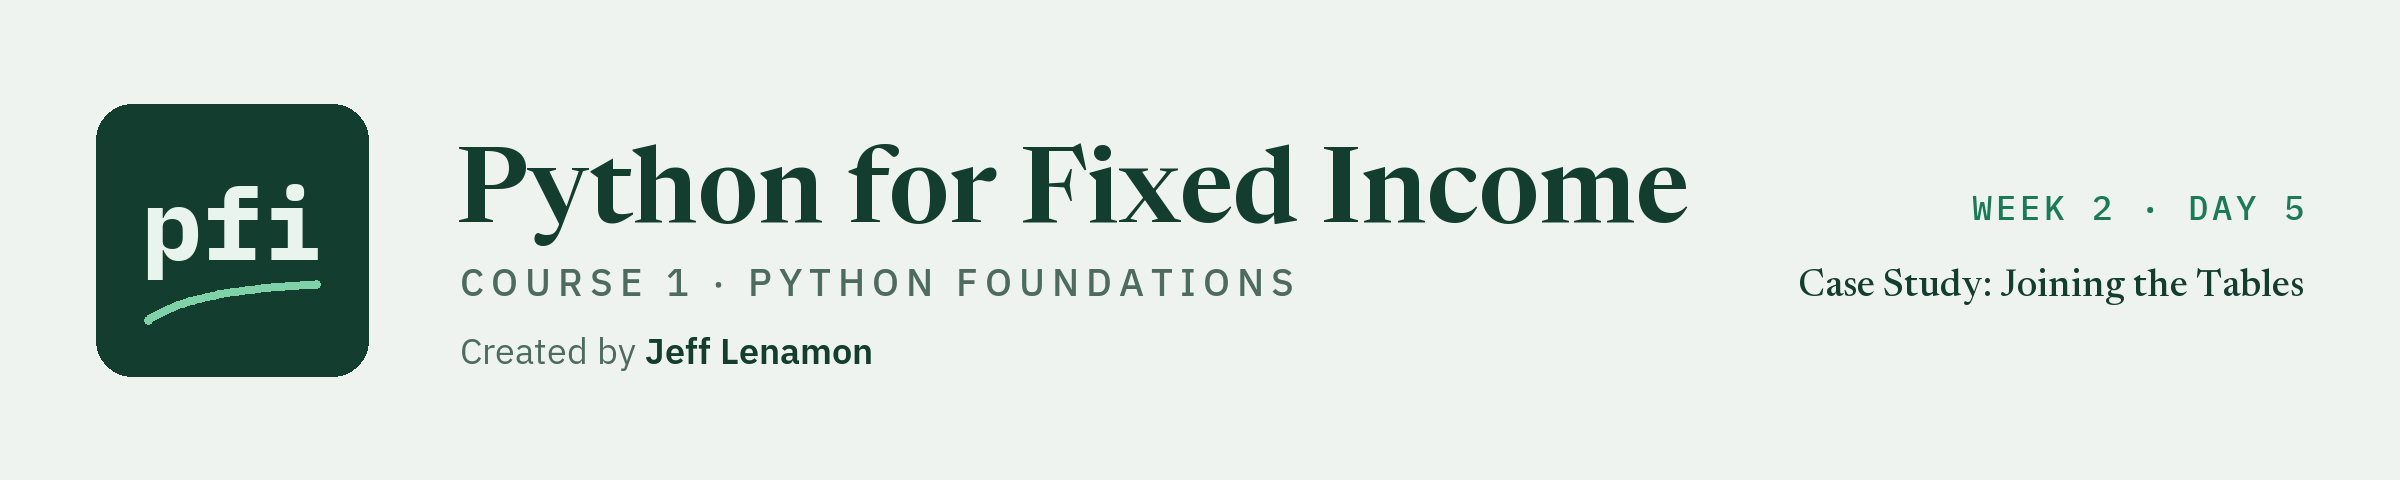

# Case Study: Joining the Tables

Week 2. The three tables checked yesterday are joined into one book, and the desk's questions are answered from it.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week2/day5/10_case_study_joining_the_tables.ipynb)

## Problem Definition

### Context

Yesterday three files arrived from three systems: the positions from the trading system, the issuer details from the reference data system, and the rating scale. Each one was checked on its own and then against the others. The report to the desk was that the three tables are clean and that they fit together.

Today they are joined. The desk has been waiting for this: a position can be reported by sector, by rating, or by grade only once its issuer's details sit on the same row.

### Objective

You are the desk's analyst. Your job today is to:

* build one table, the **book**, with one row per bond and every attribute the desk needs,
* prove that nothing was lost and nothing was duplicated on the way, and
* answer the desk's questions from that one table.

### What yesterday found

| Finding | Value |
| --- | --- |
| Positions | 200 rows, 6 columns, one row per bond held |
| Issuers | 150 rows, 5 columns, one row per issuer |
| Ratings | 18 rows, 4 columns, one row per rating |
| Total face held | 489,000,000 |
| Missing values and duplicate rows | none in any table |
| Keys | `ticker` is unique in the issuers table, `rating` is unique in the ratings table |
| Issuers held | 115 of the 150. The other 35 have no position. |
| Expected result of positions joined to issuers on `ticker` | 200 rows, 10 columns |
| Expected result of that joined to ratings on `rating` | 200 rows, 13 columns |
| Carried forward | `maturity` is text and must be converted to a date |

Every one of these is checked again today, at the point where it matters.

The conventions are the same as yesterday. Every bond is a fixed-rate bullet bond paying semiannual coupons. `coupon` is in percent, `price` is the clean price per 100 of face, and `par_held` is the face amount in dollars. The as-of date is 2026-09-30. The issuers and the CUSIPs are invented.

### The questions the desk wants answered

1. How much value and how many bonds are in each sector?
2. How is the book split between Investment Grade and High Yield, by value and by count?
3. How much value is in each rating bucket, from AAA down to CCC?
4. What are the average coupon and the average rating score, simple and value-weighted?
5. How does each sector split between the two grades?
6. Which are the ten largest issuers, and what share of the book are they together?
7. How much value is in each maturity bucket?
8. How many bonds, and how much value, are priced below par in each grade?
9. Which bonds mature within three years?

Questions 1 to 5 and 8 need a sector, a score, a bucket, or a grade, and none of those is in the positions file. Question 6 needs the issuer's name. Questions 7 and 9 need the maturity as a date.

## 1.0 Building the book

Two joins, in the order planned yesterday: positions to issuers on `ticker`, then that result to ratings on `rating`. Around each join goes the same check: count the rows and add up the face before, and again after. If both numbers are unchanged, the join lost nothing and duplicated nothing.

### 1.1 Loading the three tables

Q. Import pandas and check which version is running.

In [1]:
# os is used to find the data folder and, at the end, to delete the files this notebook writes
import os

# NumPy is used for np.isclose(), which compares numbers that have decimals
import numpy as np
import pandas as pd

print(f'pandas version: {pd.__version__}')

pandas version: 3.0.6


* This notebook was saved with pandas 3.0.6. Your version may differ, and in Google Colab it may be older.
* As yesterday: a column of text has the type `str` in pandas 3 and `object` in older versions. Wherever an output below says `str`, an older version says `object`.

Q. Find the data folder and read the three files.

In [2]:
# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../../data/positions.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

positions = pd.read_csv(data_folder + 'positions.csv')
issuers = pd.read_csv(data_folder + 'issuers.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

print('positions:', positions.shape)
print('issuers:', issuers.shape)
print('ratings:', ratings.shape)

positions: (200, 6)
issuers: (150, 5)
ratings: (18, 4)


* (200, 6), (150, 5), and (18, 4): the three shapes from yesterday's summary. The files have not changed overnight.

Q. Before anything is joined, write down the two numbers that every join will be checked against.

In [3]:
# the row count and the total face of the positions, as they arrived
rows_before = positions.shape[0]
face_before = positions['par_held'].sum()

print('Rows:', rows_before)
print('Total face:', face_before)

Rows: 200
Total face: 489000000


* 200 rows and 489,000,000 of face. These two are stored under names, so the check after each join compares against them and nobody has to remember a number.

### 1.2 Positions to issuers

The first join gives each bond its issuer's name, sector, country, and rating. The positions are the left table, because they are the rows the desk wants to keep. The issuers are the lookup.

**Predict 1**

```
step_one = pd.merge(positions, issuers, on='ticker', how='left', validate='many_to_one')
print(step_one.shape)
```

The positions have 200 rows and 6 columns. The issuers have 150 rows and 5 columns. What is printed?

> A) (150, 10)
>
> B) (200, 10)
>
> C) (350, 11)

Decide, then run the cell.

In [4]:
# how='left' keeps every row of the left table, the positions.
# validate='many_to_one' stops the merge if a ticker is listed twice in the issuers table.
step_one = pd.merge(positions, issuers, on='ticker', how='left', validate='many_to_one')
print(step_one.shape)

(200, 10)


* The answer is B: (200, 10), as yesterday's section 5.5 said it would be.
* A left merge returns the rows of the left table, one for one, as long as each key appears once in the lookup. The 150 rows of the issuers table are looked up, not added.
* Ten columns: six from the positions plus five from the issuers, minus one, because `ticker` is in both and is kept once.
* `validate='many_to_one'`, from the last pandas notebook, makes pandas test the lookup before it joins: many positions may share a ticker, and the issuers table must list each ticker once. The test passed, so there was no `MergeError`. Yesterday's `is_unique` test said it would.

Q. Run the check: rows and total face, before and after.

In [5]:
print(f'Rows before: {rows_before:,}  after: {step_one.shape[0]:,}')
print(f"Face before: {face_before:,}  after: {step_one['par_held'].sum():,}")

# both comparisons must print True
print(f'Rows unchanged: {step_one.shape[0] == rows_before}')
print(f"Face unchanged: {step_one['par_held'].sum() == face_before}")

# assert stops the notebook with an AssertionError and the message if a condition is False
assert step_one.shape[0] == rows_before, 'the merge changed the row count'
assert step_one['par_held'].sum() == face_before, 'the merge changed the total face'

Rows before: 200  after: 200
Face before: 489,000,000  after: 489,000,000
Rows unchanged: True
Face unchanged: True


* 200 and 200, 489,000,000 and 489,000,000. True and True.
* This cell comes back after every join today. It is the difference between believing a join worked and knowing it.
* The printed lines are for the reader. The two `assert` lines, from day 3 of week 1, are for the notebook: they print nothing when they pass, and they stop the run with their message when they fail. A printed False would let every later cell run on a bad table.
* The face is a total of whole dollars, so `==` is an exact test. A total with decimals takes `np.isclose()`, which comes up in section 2.6.

Q. A left merge keeps a position even when its ticker is not found, and leaves gaps in the new columns. Did that happen to any row?

In [6]:
# missing values in the four columns the lookup brought in
step_one[['issuer', 'sector', 'country', 'rating']].isna().sum()

issuer     0
sector     0
country    0
rating     0
dtype: int64

* Zero in all four. Every position found its issuer, which is what yesterday's `isin()` test promised.

Q. What do the first rows look like now?

In [7]:
step_one.head(4)

,cusip,ticker,coupon,maturity,price,par_held,issuer,sector,country,rating
0,99080CAE8,BEZE,7.000,2032-06-18,106.727,5000000,Bezane Finance,Financials,US,BBB-
1,99049XAE2,BEZH,8.125,2029-04-17,97.556,250000,Bezamyth Machinery,Industrials,US,B
2,99039NAC0,BEZL,5.125,2030-06-03,98.730,1500000,Bezoquil Freight,Transportation,US,BB
3,99039NAG1,BEZL,6.125,2053-04-09,92.261,500000,Bezoquil Freight,Transportation,US,BB


* The six columns of the positions, followed by `issuer`, `sector`, `country`, and `rating`. The first bond, the BEZE 7% of 2032, now reads Bezane Finance, Financials, US, rated BBB-.
* Rows 2 and 3 are the two BEZL bonds. Both carry the same issuer details, copied from the one BEZL row of the issuers table.

**Excel side by side.** This join is a lookup formula filled down the positions sheet, once for each column wanted:

| Column brought in | pandas | Excel |
| --- | --- | --- |
| All four at once | `pd.merge(positions, issuers, on='ticker', how='left')` | four formulas, one per column |
| Sector only | `pd.merge(positions, issuers[['ticker', 'sector']], on='ticker', how='left')` | `=VLOOKUP(B2, issuers!A:E, 3, FALSE)` |
| Sector, in Microsoft 365 and Excel 2021 or later | the same line | `=XLOOKUP(B2, issuers!A:A, issuers!C:C)` |

A failed lookup shows `#N/A` in Excel and `NaN` in pandas. The `isna()` count above is the same as filtering the sheet for `#N/A`.

The desk's second question is the split by grade. Can this table answer it yet?

In [8]:
# add up the face in each grade
step_one.groupby('grade')['par_held'].sum()

KeyError: 'grade'

* A `KeyError`, and the last line of the traceback names the problem: `'grade'`. Read it from the bottom, as in week 1. A `KeyError` on a table means a column with that name was asked for and is not there.
* The table has a `rating` column, with values such as BBB- and BB+. Which of those are Investment Grade is not written anywhere in it. The grade, the bucket, and the score are in the ratings table.
* The cure for this error is to print `step_one.columns.tolist()` and read the names. Here the column is missing because the second join has not been done.

### 1.3 Then to ratings

Q. Join the result to the rating scale on `rating`, and call the result `book`.

In [9]:
# the left table is the result of the first join. The lookup is the rating scale, which must list each rating once.
book = pd.merge(step_one, ratings, on='rating', how='left', validate='many_to_one')
print(book.shape)

(200, 13)


* (200, 13): 200 rows, and the ten columns plus four from the ratings minus the shared `rating`.

Q. Run the check again.

In [10]:
print(f'Rows before: {rows_before:,}  after: {book.shape[0]:,}')
print(f"Face before: {face_before:,}  after: {book['par_held'].sum():,}")

print(f'Rows unchanged: {book.shape[0] == rows_before}')
print(f"Face unchanged: {book['par_held'].sum() == face_before}")

# the same two checks, as statements that stop the notebook on a failure
assert book.shape[0] == rows_before, 'the second merge changed the row count'
assert book['par_held'].sum() == face_before, 'the second merge changed the total face'

Rows before: 200  after: 200
Face before: 489,000,000  after: 489,000,000
Rows unchanged: True
Face unchanged: True


* True and True again, and both `assert` lines passed in silence. Two joins, and the book still has 200 rows and 489,000,000 of face.

Q. Did every rating find its row in the scale? And what are the 13 columns?

In [11]:
print(book[['score', 'bucket', 'grade']].isna().sum())
print()
print(book.columns.tolist())

score     0
bucket    0
grade     0
dtype: int64

['cusip', 'ticker', 'coupon', 'maturity', 'price', 'par_held', 'issuer', 'sector', 'country', 'rating', 'score', 'bucket', 'grade']


* No gaps in the three new columns.
* Thirteen columns: `cusip`, `ticker`, `coupon`, `maturity`, `price`, and `par_held` from the positions, `issuer`, `sector`, `country`, and `rating` from the issuers, and `score`, `bucket`, and `grade` from the ratings.
* Yesterday's promise is kept: 200 rows, 13 columns, 489,000,000 of face.

Q. Show one row of the book.

In [12]:
# the first row, as a Series with the column names as labels
book.iloc[0]

cusip              99080CAE8
ticker                  BEZE
coupon                   7.0
maturity          2032-06-18
price                106.727
par_held             5000000
issuer        Bezane Finance
sector            Financials
country                   US
rating                  BBB-
score                     10
bucket                   BBB
grade       Investment Grade
Name: 0, dtype: object

* One row is still **one bond the desk holds**. It now carries everything the three systems know about it: its terms and size, its issuer, and what its rating means.
* The last line reads `dtype: object` in every version of pandas, because a row mixes text and numbers.

Q. Yesterday the six NEVX bonds pointed to one row of the issuers table. What do they look like in the book?

In [13]:
# loc with a mask for the rows and a list of names for the columns
book.loc[book['ticker'] == 'NEVX', ['cusip', 'coupon', 'issuer', 'sector', 'rating', 'score', 'grade']]

,cusip,coupon,issuer,sector,rating,score,grade
113,99054CAF7,4.625,Nevulex Health,Health Care,BBB-,10,Investment Grade
114,99054CAB6,6.250,Nevulex Health,Health Care,BBB-,10,Investment Grade
115,99054CAC4,6.250,Nevulex Health,Health Care,BBB-,10,Investment Grade
116,99054CAD2,6.125,Nevulex Health,Health Care,BBB-,10,Investment Grade
117,99054CAG5,3.875,Nevulex Health,Health Care,BBB-,10,Investment Grade
118,99054CAH3,5.250,Nevulex Health,Health Care,BBB-,10,Investment Grade


* Six bonds, six CUSIPs, and the same issuer details on each: Nevulex Health, Health Care, BBB-, score 10, Investment Grade.
* The one issuer row was copied onto six bond rows. That is what many-to-one means, and it is why the row count stayed at 200.

And the question that failed a moment ago?

In [14]:
book.groupby('grade')['par_held'].sum()

grade
High Yield          169250000
Investment Grade    319750000
Name: par_held, dtype: int64

* The same line, with `book` in place of `step_one`, now runs: 169,250,000 of face in High Yield and 319,750,000 in Investment Grade. The two add up to 489,000,000.

### 1.4 What could have gone wrong

Both joins returned what was expected. It is worth seeing what the same data returns when the join is written a little differently, because none of these raises an error.

**Predict 2**

`how='outer'` keeps every key from either table.

```
everything = pd.merge(positions, issuers, on='ticker', how='outer', indicator=True)
print(everything.shape)
```

The positions have 200 rows and 115 distinct tickers. The issuers table has 150 rows. What is printed?

> A) (200, 11)
>
> B) (235, 11)
>
> C) (350, 11)

Decide, then run the cell.

In [15]:
# indicator=True adds a column named _merge that says where each row came from
everything = pd.merge(positions, issuers, on='ticker', how='outer', indicator=True)
print(everything.shape)

(235, 11)


* The answer is B: 235 rows. The 200 positions, plus one row for each of the 35 issuers that have no position. Yesterday's section 5.5 gave the same number.
* Eleven columns: the ten from before plus `_merge`.

Q. Count the rows by where they came from.

In [16]:
everything['_merge'].value_counts()

_merge
both          200
right_only     35
left_only       0
Name: count, dtype: int64

* 200 rows are `both`: a position that found its issuer. 35 are `right_only`: an issuer in the reference data with no position. None is `left_only`, so no position is without an issuer.
* 200 plus 35 is 235, and 115 issuers held plus 35 not held is 150. Both of yesterday's counts are confirmed by the join itself.

Q. What does a `right_only` row look like?

In [17]:
no_position = everything[everything['_merge'] == 'right_only']
no_position[['ticker', 'issuer', 'cusip', 'price', 'par_held', '_merge']].head(4)

,ticker,issuer,cusip,price,par_held,_merge
7,BEZY,Bezolvey Chemicals,NaN,NaN,NaN,right_only
10,BRUN,Bruxiskan Pipeline,NaN,NaN,NaN,right_only
11,BRUR,Bruxazor Logistics,NaN,NaN,NaN,right_only
13,CLAH,Clavamyth Health,NaN,NaN,NaN,right_only


* An issuer with a name and nothing else: `NaN` under `cusip`, `price`, and `par_held`, because there is no bond to fill them.
* These 35 rows are not errors in the data. They are issuers the reference system knows and the desk does not hold. In a table that is meant to have one row per bond held, they do not belong.

Q. Suppose a report had been built on this table by mistake. Which of the two checks would catch it?

In [18]:
print('Rows:', everything.shape[0])
print('Rows with a CUSIP:', everything['cusip'].count())
print('Total face:', everything['par_held'].sum())

Rows: 235
Rows with a CUSIP: 200
Total face: 489000000.0


* The face check passes: 489,000,000, because `sum()` skips the 35 missing values. The total is shown with a decimal point because a column that holds `NaN` is stored as decimals.
* The row check fails: 235 against 200. A count of bonds by sector taken on this table would be too high by up to 35.
* That is why the check has two parts. Extra rows with no face pass the first and fail the second.

Q. Run the row check from section 1.2 on this table, as an `assert`.

In [19]:
# the outer merge has 235 rows, so this condition is False
assert everything.shape[0] == rows_before, f'expected {rows_before:,} rows and found {everything.shape[0]:,}'

AssertionError: expected 200 rows and found 235

* An `AssertionError`, and its last line is our message: expected 200 rows and found 235. When the whole notebook is run from the top, it stops at this line, before any report is built on the table.
* The message is an f-string, so it carries both numbers. A message that says what was expected and what was found saves the next reader a step.

**Predict 3**

The opposite case: a lookup table in which a key appears twice. This is tried on a small copy, not on the real tables. The copy has the first four positions, and a lookup in which BEZL is listed twice.

```
small = positions[['cusip', 'ticker', 'par_held']].head(4)
small_lookup = issuers.loc[issuers['ticker'].isin(['BEZE', 'BEZH', 'BEZL']), ['ticker', 'sector']]
bezl_again = small_lookup[small_lookup['ticker'] == 'BEZL']
lookup_twice = pd.concat([small_lookup, bezl_again], ignore_index=True)

doubled = pd.merge(small, lookup_twice, on='ticker', how='left')
```

The four positions are BEZE, BEZH, and two BEZL bonds, with 7,250,000 of face in total. How many rows does `doubled` have, and how much face?

> A) 4 rows and 7,250,000. A left merge keeps the rows of the left table.
>
> B) 5 rows and 7,750,000. The repeated ticker adds one row.
>
> C) 6 rows and 9,250,000. Each of the two BEZL bonds matches twice.

Decide, then run the cell.

In [20]:
# four positions, and a lookup that lists BEZL twice
small = positions[['cusip', 'ticker', 'par_held']].head(4)
small_lookup = issuers.loc[issuers['ticker'].isin(['BEZE', 'BEZH', 'BEZL']), ['ticker', 'sector']]
bezl_again = small_lookup[small_lookup['ticker'] == 'BEZL']
lookup_twice = pd.concat([small_lookup, bezl_again], ignore_index=True)

doubled = pd.merge(small, lookup_twice, on='ticker', how='left')
print(doubled)
print()
print('Face before:', small['par_held'].sum(), ' after:', doubled['par_held'].sum())

       cusip ticker  par_held          sector
0  99080CAE8   BEZE   5000000      Financials
1  99049XAE2   BEZH    250000     Industrials
2  99039NAC0   BEZL   1500000  Transportation
3  99039NAC0   BEZL   1500000  Transportation
4  99039NAG1   BEZL    500000  Transportation
5  99039NAG1   BEZL    500000  Transportation

Face before: 7250000  after: 9250000


* The answer is C. Six rows from four, and 9,250,000 of face from 7,250,000. Each BEZL bond matched both BEZL rows of the lookup, so each appears twice: 1,500,000 and 500,000 were counted a second time.
* 'A left merge keeps the rows of the left table' is true only when each key appears once in the lookup. Yesterday's `is_unique` test on `issuers['ticker']` is what made it true for the real tables.
* This time both parts of the check fail, rows and face. There was still no error.
* With `validate='many_to_one'`, as on the two real merges above, pandas refuses this merge with a `MergeError`, because BEZL is listed twice in the lookup.

**Excel side by side.** `VLOOKUP` and `XLOOKUP` return the first match and stop, so a repeated key in the lookup sheet never adds a row in Excel. It also never tells you the key was repeated. pandas returns every match. Each tool hides the problem in its own way, and in both the cure is to test the key before the lookup.

Q. The default, `how='inner'`, keeps only the keys found in both tables. What does it return here?

In [21]:
inner = pd.merge(positions, issuers, on='ticker', how='inner')
print(inner.shape)
print('Face:', inner['par_held'].sum())

(200, 10)
Face: 489000000


* (200, 10) and 489,000,000: the same as the left merge, because every position has an issuer.
* On these tables the two agree. They differ on the day a new bond arrives before its issuer is set up in the reference data. An inner merge would drop that bond with no message. A left merge keeps it, with gaps that `isna()` can count. For a table that must keep every position, `how='left'` followed by the check is the habit.

| Join written as | Rows | Face | Caught by |
| --- | --- | --- | --- |
| left, each key once in the lookup | 200 | 489,000,000 | nothing to catch |
| outer | 235 | 489,000,000 | the row check |
| left, a key repeated in the lookup | more than the left table | too high | both checks, and `validate='many_to_one'` before them |
| inner, a key missing from the lookup | fewer than the left table | too low | both checks |

**Observations: building the book**

* Two left merges produced one table of 200 rows and 13 columns.
* Rows and total face were checked before and after each merge and did not change: 200 rows, 489,000,000 of face. The checks are `assert` statements, and both merges carry `validate='many_to_one'`.
* No position is missing an issuer, and no rating is missing from the scale.
* The 35 issuers with no position stay out of the book.

## 2.0 Preparing the book

The book has every attribute the three files carry. The desk's questions need a few more columns that no file carries and that can be worked out from the ones that are there: a real date, a value, the coupon income, the years left, a maturity bucket, and a weight.

### 2.1 Maturity as a date

Q. Yesterday the maturity was found to be text. Is it still?

In [22]:
print(book['maturity'].dtype)
print(book['maturity'].iloc[0])

str
2032-06-18


* `str`, or `object` in older versions of pandas. A merge copies columns as they are and does not change their type.

Q. Convert the column to dates, in place.

In [23]:
# to_datetime() reads the text and returns dates. Assigning back replaces the column.
book['maturity'] = pd.to_datetime(book['maturity'])

print(book['maturity'].dtype)
print('Earliest:', book['maturity'].min().date())
print('Latest:', book['maturity'].max().date())

datetime64[us]
Earliest: 2027-10-02
Latest: 2056-08-23


* The type is now `datetime64[us]`. Older versions of pandas show `datetime64[ns]`. Both are dates.
* The maturities run from 2027-10-02 to 2056-08-23, the same two dates as yesterday. Yesterday the dates went into a separate Series and the table was left alone. Today the column itself is replaced, because the book is ours to prepare.

### 2.2 Value at the clean price

The desk reports by value, not by face. The positions file has a clean price and no accrued interest, so the value that can be calculated here is:

**value = face x clean price / 100**

That is the value of the position **at the clean price, before accrued interest**. It is not a full market value, which would add the accrued interest. Everything called `value` in this notebook is this figure.

Q. Add the column.

In [24]:
# price is per 100 of face, so divide by 100
book['value'] = book['par_held'] * book['price'] / 100

book[['cusip', 'price', 'par_held', 'value']].head(3)

,cusip,price,par_held,value
0,99080CAE8,106.727,5000000,5336350.0
1,99049XAE2,97.556,250000,243890.0
2,99039NAC0,98.730,1500000,1480950.0


* The first bond: 5,000,000 of face at 106.727 is 5,336,350. The second: 250,000 at 97.556 is 243,890.
* The arithmetic runs down all 200 rows at once, as in the earlier notebooks.

**Predict 4**

Yesterday's summary gave the average price of the 200 bonds as about 98.83. Total face is 489,000,000.

```
total_value = book['value'].sum()
```

Is the total value above, below, or equal to the total face?

> A) Above 489,000,000.
>
> B) Below 489,000,000.
>
> C) Equal to 489,000,000. The premiums and the discounts cancel out.

Decide, then run the cell.

In [25]:
total_value = book['value'].sum()

print('Total face:', face_before)
print('Total value:', total_value)
print('Value per 100 of face:', round(total_value / face_before * 100, 3))

Total face: 489000000
Total value: 483024230.0
Value per 100 of face: 98.778


* The answer is B. The total value is 483,024,230, about 5,975,770 less than the face.
* Value per 100 of face is 98.778. That is the average price with each bond counted by its face. It is close to the simple average of 98.83 and not equal to it, because the positions are not all the same size.
* An average price below 100 made B the likely answer. It did not guarantee it: a few large positions at high prices could have pushed the total above the face. Only the sum settles it.
* `total_value` is stored under a name. It is the denominator of every share from here on.

### 2.3 Annual coupon income

Q. How much coupon does each position pay in a year, in dollars? And the whole book?

In [26]:
# coupon is in percent of face, so divide by 100
book['coupon_income'] = book['par_held'] * book['coupon'] / 100

print(book[['cusip', 'coupon', 'par_held', 'coupon_income']].head(3))
print()
print('Annual coupon income of the book:', book['coupon_income'].sum())

       cusip  coupon  par_held  coupon_income
0  99080CAE8   7.000   5000000       350000.0
1  99049XAE2   8.125    250000        20312.5
2  99039NAC0   5.125   1500000        76875.0

Annual coupon income of the book: 28864375.0


* The first bond pays 7 percent on 5,000,000 of face: 350,000 a year, in two semiannual payments of 175,000.
* The book as a whole pays 28,864,375 a year in coupons. This is a count of contractual coupon dollars at today's holdings and nothing more.

### 2.4 Years to maturity

Q. How many years does each bond have left, counted from the as-of date?

In [27]:
as_of = pd.Timestamp('2026-09-30')

# a date minus a date is a length of time. .dt.days gives it as a number of days.
days_left = (book['maturity'] - as_of).dt.days
book['years_to_maturity'] = days_left / 365.25

print('Shortest:', round(book['years_to_maturity'].min(), 2))
print('Longest:', round(book['years_to_maturity'].max(), 2))
print('Average:', round(book['years_to_maturity'].mean(), 2))

Shortest: 1.0
Longest: 29.9
Average: 9.85


* From 1.0 to 29.9 years, with a simple average of 9.85.
* Dividing the days by 365.25 is an **approximation**. It is calendar days over an average year length, and it is good enough to sort bonds into buckets. It is not a day count convention, and it is not what a pricing calculation uses.

### 2.5 Maturity bucket

Q. Put every bond in a maturity bucket: 0 to 3 years, 3 to 7, 7 to 15, and 15 and over.

In [28]:
# pd.cut() sorts numbers into ranges. bins= lists the edges and labels= names the ranges between them.
edges = [0, 3, 7, 15, 100]
names = ['0 to 3', '3 to 7', '7 to 15', '15 and over']
book['maturity_bucket'] = pd.cut(book['years_to_maturity'], bins=edges, labels=names)

# sort_index() lists the buckets from short to long
book['maturity_bucket'].value_counts().sort_index()

maturity_bucket
0 to 3         28
3 to 7         51
7 to 15        88
15 and over    33
Name: count, dtype: int64

* 28 bonds in 0 to 3 years, 51 in 3 to 7, 88 in 7 to 15, and 33 in 15 and over. The four counts add up to 200, so every bond landed in a bucket.
* Each range includes its upper edge, as in the last notebook. The last edge, 100, is a number no maturity reaches.
* The last line of the output gives the type of the counts. The bucket column itself has the type `category`, which is how pandas stores a column with a fixed set of ordered labels.

### 2.6 Weight

Q. What percent of the book's value is each bond? Show the three largest.

In [29]:
# each bond's value as a percent of the total
book['weight_pct'] = book['value'] / total_value * 100

book.nlargest(3, 'weight_pct')[['cusip', 'issuer', 'par_held', 'price', 'value', 'weight_pct']]

,cusip,issuer,par_held,price,value,weight_pct
0,99080CAE8,Bezane Finance,5000000,106.727,5336350.0,1.104779
59,99021VAC2,Feskundra Systems,5000000,106.471,5323550.0,1.102129
104,99144OAF3,Lorvellix Energy,5000000,104.801,5240050.0,1.084842


* The three largest positions are 1.10, 1.10, and 1.08 percent of the book. All three are 5,000,000 of face, the largest position size in the file, at prices above par.
* The weight is in percent, and the name says so: `weight_pct`.
* These weights are on value at the clean price, because the positions file has no accrued interest. Desk weights are normally on market value including accrued, which is how the `weight_pct` column of the pandas notebook was built from the holdings file. The two columns share a name and differ slightly. Exercise 4 adds the accrued interest back.

Q. Do the weights add up to 100?

In [30]:
print(f"Sum of the weights: {round(book['weight_pct'].sum(), 6)}")

# the weights have decimals, so the test is np.isclose(), from the NumPy notebook, and not ==
assert np.isclose(book['weight_pct'].sum(), 100), 'the weights do not add up to 100'

Sum of the weights: 100.0


* 100.0. Every bond's value was divided by the same total, so the shares must add back to the whole.
* The sum is rounded before it is printed. Decimal arithmetic on a computer can leave a result a hair away from 100, such as 99.99999999999999, and that is not an error in the weights.
* The `assert` uses `np.isclose()` for the same reason. `==` asks for identical digits, and a correct weight column can miss 100 in the last one.

**Excel side by side.** Each new column is a helper column filled down the sheet:

| Column | pandas | Excel, row 2 |
| --- | --- | --- |
| Value | `book['par_held'] * book['price'] / 100` | `=F2 * E2 / 100` |
| Coupon income | `book['par_held'] * book['coupon'] / 100` | `=F2 * C2 / 100` |
| Years to maturity | `(book['maturity'] - as_of).dt.days / 365.25` | `=(D2 - DATE(2026, 9, 30)) / 365.25` |
| Weight | `book['value'] / total_value * 100` | `=N2 / SUM($N$2:$N$201) * 100` |

In Excel the dollar signs hold the total in place as the formula is filled down. In pandas the total is one stored number, and there is nothing to anchor.

Q. What does the finished book hold?

In [31]:
print(book.shape)
print()
print(book.dtypes)

(200, 18)

cusip                           str
ticker                          str
coupon                      float64
maturity             datetime64[us]
price                       float64
par_held                      int64
issuer                          str
sector                          str
country                         str
rating                          str
score                         int64
bucket                          str
grade                           str
value                       float64
coupon_income               float64
years_to_maturity           float64
maturity_bucket            category
weight_pct                  float64
dtype: object


* (200, 18): the 13 joined columns plus five prepared ones. Still 200 rows.
* The text columns show `str` here and `object` in older versions of pandas. `maturity` is a date, shown as `datetime64[us]` here and `datetime64[ns]` in older versions. `maturity_bucket` is `category`. The rest are numbers.

**Observations: preparing the book**

* The maturity is a date, running from 2027-10-02 to 2056-08-23.
* Value at the clean price, before accrued interest, totals 483,024,230 on 489,000,000 of face.
* Annual coupon income is 28,864,375.
* Years to maturity, by calendar days over 365.25, run from 1.0 to 29.9.
* Every bond has a maturity bucket and a weight, and the weights add up to 100.

## 3.0 Answering the desk's questions

The book is built and checked. Each question below is answered from it with tools from the last three notebooks.

One rule for this whole section: **the answers describe the data and are not a view.** They are sizes, counts, shares, and averages of an invented portfolio. They say what the book holds. They do not say whether any of it is good or bad, and they suggest no trade.

Every figure called value is value at the clean price, before accrued interest.

### 3.1 Value and number of bonds by sector

Q. How many bonds, and how much value, are in each sector?

In [32]:
# each line reads: new column name = (column to use, statistic)
by_sector = book.groupby('sector').agg(
    bonds=('cusip', 'count'),
    value=('value', 'sum'),
)
by_sector

,bonds,value
sector,,
Consumer,26,55773490.0
Energy,17,38258305.0
Financials,26,67067357.5
Health Care,20,38268482.5
Industrials,20,51658930.0
Materials,26,70527440.0
Technology,12,29826430.0
Telecom,21,54953580.0
Transportation,20,48159510.0


* Ten sectors in alphabetical order, with a count and a total for each. The `sector` column came from the issuers table, so this is the first answer that needed the join.

Q. Add each sector's share of the book, and list the largest first.

In [33]:
by_sector['pct_of_value'] = (by_sector['value'] / total_value * 100).round(2)
by_sector = by_sector.sort_values('value', ascending=False)
by_sector

,bonds,value,pct_of_value
sector,,,
Materials,26,70527440.0,14.60
Financials,26,67067357.5,13.88
Consumer,26,55773490.0,11.55
Telecom,21,54953580.0,11.38
Industrials,20,51658930.0,10.69
Transportation,20,48159510.0,9.97
Health Care,20,38268482.5,7.92
Energy,17,38258305.0,7.92
Technology,12,29826430.0,6.17


In [34]:
# the checks on a grouped table: the parts must add back to the whole
print(f"Bonds: {by_sector['bonds'].sum():,}")
print(f"Value: {by_sector['value'].sum():,.0f}")

# a count is exact, so it is tested with ==. A value has decimals, so it is tested with np.isclose().
assert by_sector['bonds'].sum() == rows_before, 'the sector counts do not add up to the number of bonds'
assert np.isclose(by_sector['value'].sum(), total_value), 'the sector values do not add up to the total value'

Bonds: 200
Value: 483,024,230


* 200 bonds and 483,024,230 of value. The ten groups account for the whole book.

**Observations**

* Materials has the most value, 70,527,440, which is 14.60 percent of the book. Financials is next with 67,067,357.5, or 13.88 percent, and Consumer third with 55,773,490, or 11.55 percent. Each of the three has 26 bonds.
* Utilities has the least, 28,530,705, or 5.91 percent, on 12 bonds. Technology also has 12 bonds, with 29,826,430.
* Health Care and Energy are within about 10,000 of each other in value, 38,268,482.5 and 38,258,305, on 20 and 17 bonds.

**Excel side by side.** This is a pivot table: `sector` in Rows, Count of `cusip` and Sum of `value` in Values, and the value shown a second time as % of Grand Total. `groupby` with `agg` is the pivot table written as a line of code that can be run again tomorrow on a new file.

### 3.2 Investment Grade and High Yield

Q. How many bonds and how much value are in each grade?

In [35]:
by_grade = book.groupby('grade').agg(
    bonds=('cusip', 'count'),
    value=('value', 'sum'),
)
by_grade

,bonds,value
grade,,
High Yield,72,166398102.5
Investment Grade,128,316626127.5


* 128 Investment Grade bonds with 316,626,127.5 of value, and 72 High Yield bonds with 166,398,102.5.

Q. What are the two shares, by count and by value?

In [36]:
by_grade['pct_of_bonds'] = (by_grade['bonds'] / by_grade['bonds'].sum() * 100).round(2)
by_grade['pct_of_value'] = (by_grade['value'] / total_value * 100).round(2)
by_grade

,bonds,value,pct_of_bonds,pct_of_value
grade,,,,
High Yield,72,166398102.5,36.0,34.45
Investment Grade,128,316626127.5,64.0,65.55


**Observations**

* By count, the book is 64.0 percent Investment Grade and 36.0 percent High Yield: 128 and 72 of 200 bonds.
* By value, it is 65.55 percent Investment Grade and 34.45 percent High Yield.
* The two measures differ by about a point and a half. A share by count treats every bond alike, and a share by value counts each bond by its size. When a share is quoted, it should say which one it is.

**Excel side by side.**

| Question | pandas | Excel |
| --- | --- | --- |
| Bonds in High Yield | `by_grade.loc['High Yield', 'bonds']` | `=COUNTIF(M:M, "High Yield")` |
| Value in High Yield | `by_grade.loc['High Yield', 'value']` | `=SUMIF(M:M, "High Yield", N:N)` |
| Share of value | divide by `total_value` | `=SUMIF(M:M, "High Yield", N:N) / SUM(N:N)` |

The formulas assume the grade in column M and the value in column N of the joined sheet.

### 3.3 Value by rating bucket

**Predict 5**

The book has seven rating buckets. From the highest rating to the lowest they are AAA, AA, A, BBB, BB, B, and CCC.

```
book.groupby('bucket')['value'].sum()
```

In what order will the seven buckets be listed?

> A) AAA, AA, A, BBB, BB, B, CCC: credit order.
>
> B) A, AA, AAA, B, BB, BBB, CCC: alphabetical order.
>
> C) Largest value first.

Decide, then run the cell.

In [37]:
book.groupby('bucket')['value'].sum()

bucket
A      146730275.0
AA      12928850.0
AAA      8102725.0
B       42653482.5
BB     111511485.0
BBB    148864277.5
CCC     12233135.0
Name: value, dtype: float64

* The answer is B. `groupby` sorts the group names as text, and as text `A` comes before `AA`, which comes before `AAA`, which comes before `B`.
* Alphabetical order is wrong for ratings. It puts AAA third, between AA and B, and splits the Investment Grade buckets with B and BB in the middle of them. A reader scanning down the table for where the book thins out would be misled by the order alone.
* The bucket is text, and text knows nothing about credit quality. The `score` does: 1 for AAA, rising by one for each notch lower.

Q. List the buckets in credit order, using the score.

In [38]:
# the lowest score in each bucket is carried along, and the table is sorted on it
by_bucket = book.groupby('bucket').agg(
    first_score=('score', 'min'),
    bonds=('cusip', 'count'),
    value=('value', 'sum'),
)
by_bucket = by_bucket.sort_values('first_score')
by_bucket['pct_of_value'] = (by_bucket['value'] / total_value * 100).round(2)
by_bucket

,first_score,bonds,value,pct_of_value
bucket,,,,
AAA,1,2,8102725.0,1.68
AA,2,8,12928850.0,2.68
A,5,56,146730275.0,30.38
BBB,8,62,148864277.5,30.82
BB,11,49,111511485.0,23.09
B,14,18,42653482.5,8.83
CCC,17,5,12233135.0,2.53


* Now the rows run AAA, AA, A, BBB, BB, B, CCC. The sort is on `first_score`, the lowest score found in each bucket, so the order comes from the rating scale and nobody typed it by hand.
* Last time the order was typed as a list and passed to `loc`. That works for seven buckets that never change. Sorting on the score works for any set of ratings, including one with a rating added next year.

**Observations**

* BBB and A are the two largest buckets, and nearly equal: BBB has 148,864,277.5, or 30.82 percent, on 62 bonds, and A has 146,730,275, or 30.38 percent, on 56 bonds.
* BB is third with 111,511,485, or 23.09 percent, on 49 bonds. B has 42,653,482.5, or 8.83 percent, on 18 bonds.
* The two ends of the scale are small: AAA is 1.68 percent on 2 bonds, AA is 2.68 percent on 8 bonds, and CCC is 2.53 percent on 5 bonds.
* The last three rows, BB to CCC, add up to the High Yield share of 34.45 percent from section 3.2. The first four, AAA to BBB, are the Investment Grade share. Their rounded figures add up to 65.56 against 65.55, a difference that comes from rounding each row.

### 3.4 Average coupon and average rating score

A simple average counts every bond once. A value-weighted average counts each bond by its value: multiply each bond's figure by its value, add those up, and divide by the total value. Both are built here with plain arithmetic, as in the last notebook.

Q. What is the average coupon of the book, simple and value-weighted?

In [39]:
# the simple average: every bond counts once
simple_coupon = book['coupon'].mean()

# the weighted average: a sum of coupon times value, divided by the sum of value
weighted_coupon = (book['coupon'] * book['value']).sum() / total_value

print('Simple average coupon:', round(simple_coupon, 4))
print('Value-weighted average coupon:', round(weighted_coupon, 4))

Simple average coupon: 5.9375
Value-weighted average coupon: 5.9403


* 5.9375 percent simple and 5.9403 percent value-weighted. The two differ in the third decimal place.
* They are close because coupon and position size are not strongly related in this book. The weighted figure moves away from the simple one only when the larger positions have systematically higher or lower coupons than the smaller ones.

Q. Yesterday `issuers['rating'].mean()` raised a `TypeError`, because a rating is letters. What is the average rating of the book, through the score?

In [40]:
simple_score = book['score'].mean()
weighted_score = (book['score'] * book['value']).sum() / total_value

print('Simple average score:', round(simple_score, 2))
print('Value-weighted average score:', round(weighted_score, 2))

Simple average score: 9.36
Value-weighted average score: 9.25


In [41]:
# which ratings are scores 9 and 10?
ratings[ratings['score'].isin([9, 10])]

,rating,score,bucket,grade
8,BBB,9,BBB,Investment Grade
9,BBB-,10,BBB,Investment Grade


* 9.36 simple and 9.25 value-weighted. Both fall between score 9, which is BBB, and score 10, which is BBB-.
* The weighted score is a little lower than the simple one. A lower score is a higher rating, so the book's value sits slightly more in the higher-rated bonds than its bond count does. That matches section 3.2, where Investment Grade was 64.0 percent by count and 65.55 percent by value.
* An average score is a description. It treats the step between two neighboring ratings as the same size everywhere on the scale, which is a convention of the scoring and not a fact about credit.

**Predict 6**

The book has a weight column, in percent, that adds up to 100. Someone uses it as a shortcut for the weighted average coupon:

```
shortcut = (book['coupon'] * book['weight_pct']).sum()
print(round(shortcut, 2))
```

What is printed?

> A) 5.94, the weighted average coupon.
>
> B) 594.03
>
> C) 0.06

Decide, then run the cell.

In [42]:
shortcut = (book['coupon'] * book['weight_pct']).sum()
print(round(shortcut, 2))

# weights in percent add up to 100, so divide by 100
print(round(shortcut / 100, 4))

594.03
5.9403


* The answer is B: 594.03. The weights are in percent and add up to 100, so the sum comes out 100 times too large. Divided by 100 it is 5.9403, the figure from above.
* A weighted average always divides by the sum of the weights. When the weights are values, that sum is the total value. When they are percents, it is 100. When they are decimals that add up to 1, the division can be left out, and that is the only case where it can.
* The units are in the column name for this reason. `weight_pct` says to divide by 100.

Q. What is the value-weighted average coupon of each grade?

In [43]:
# the same arithmetic, on the rows of one grade at a time
investment_grade = book[book['grade'] == 'Investment Grade']
high_yield = book[book['grade'] == 'High Yield']

ig_coupon = (investment_grade['coupon'] * investment_grade['value']).sum() / investment_grade['value'].sum()
hy_coupon = (high_yield['coupon'] * high_yield['value']).sum() / high_yield['value'].sum()

print('Investment Grade:', round(ig_coupon, 4))
print('High Yield:', round(hy_coupon, 4))

Investment Grade: 5.2212
High Yield: 7.3086


* Inside a group, the divisor is the value of that group, not the value of the whole book. Dividing the High Yield sum by `total_value` would give a number about a third of the right size, with no error.

**Observations**

* The average coupon of the book is 5.94 percent on either measure: 5.9375 simple and 5.9403 value-weighted.
* The value-weighted average coupon is 5.2212 percent for the Investment Grade bonds and 7.3086 percent for the High Yield bonds.
* The average rating score is 9.36 simple and 9.25 value-weighted, between BBB and BBB-.

**Excel side by side.**

| Average | pandas | Excel |
| --- | --- | --- |
| Simple | `book['coupon'].mean()` | `=AVERAGE(C2:C201)` |
| Value-weighted | `(book['coupon'] * book['value']).sum() / book['value'].sum()` | `=SUMPRODUCT(C2:C201, N2:N201) / SUM(N2:N201)` |

`SUMPRODUCT` multiplies the two columns row by row and adds up the results, which is what `(a * b).sum()` does.

### 3.5 Sector by grade

Q. Show the value in each sector, split by grade, with totals.

In [44]:
# index= goes down the side, columns= goes across the top, values= is the column to summarize
sector_grade = pd.pivot_table(book, values='value', index='sector', columns='grade',
                              aggfunc='sum', margins=True)
sector_grade

grade,High Yield,Investment Grade,All
sector,,,
Consumer,18539692.5,37233797.5,55773490.0
Energy,7146597.5,31111707.5,38258305.0
Financials,15000122.5,52067235.0,67067357.5
Health Care,12621225.0,25647257.5,38268482.5
Industrials,22360440.0,29298490.0,51658930.0
Materials,38003020.0,32524420.0,70527440.0
Technology,6124472.5,23701957.5,29826430.0
Telecom,27344940.0,27608640.0,54953580.0
Transportation,14052640.0,34106870.0,48159510.0


* Ten sectors down the side, the two grades across the top, and the row and column named `All` from `margins=True`.
* The corner cell is 483,024,230, the total value. The bottom row repeats the grade totals from section 3.2 and the right-hand column repeats the sector totals from section 3.1. A pivot table that did not agree with the two tables it combines would be the sign of a mistake.

Q. Show the same table as a percent of the book.

In [45]:
# every cell divided by the same total
(sector_grade / total_value * 100).round(1)

grade,High Yield,Investment Grade,All
sector,,,
Consumer,3.8,7.7,11.5
Energy,1.5,6.4,7.9
Financials,3.1,10.8,13.9
Health Care,2.6,5.3,7.9
Industrials,4.6,6.1,10.7
Materials,7.9,6.7,14.6
Technology,1.3,4.9,6.2
Telecom,5.7,5.7,11.4
Transportation,2.9,7.1,10.0


**Observations**

* Materials is the one sector with more value in High Yield than in Investment Grade: 38,003,020 against 32,524,420, or 7.9 percent of the book against 6.7.
* In Telecom the two are almost equal: 27,344,940 High Yield and 27,608,640 Investment Grade, 5.7 percent each.
* In the other eight sectors Investment Grade is the larger part. The largest single cell is Financials Investment Grade, 52,067,235, or 10.8 percent of the book.
* The smallest cell is Utilities High Yield, 5,204,952.5, or 1.1 percent.

**Excel side by side.** The same pivot table with `grade` dragged into Columns. In pandas, `index=` is the Rows box, `columns=` is the Columns box, `values=` with `aggfunc=` is the Values box, and `margins=True` is Grand Totals switched on.

### 3.6 The ten largest issuers

A sector or a grade is a property of the issuer. So is the issuer's name. The desk holds several bonds of many issuers, and a question about issuers has to add those bonds together first.

Q. How many issuers are in the book, and which ten have the most value?

In [46]:
print('Issuers in the book:', book['issuer'].nunique())

# one row per issuer: its number of bonds and their combined value
by_issuer = book.groupby('issuer').agg(
    bonds=('cusip', 'count'),
    value=('value', 'sum'),
)
top_ten = by_issuer.nlargest(10, 'value')
top_ten

Issuers in the book: 115


,bonds,value
issuer,,
Elverone Industrial,4,11112270.0
Heskundra Retail,3,10879132.5
Corvoquil Metals,3,10519955.0
Vraxorin Bancorp,3,10464405.0
Farvellix Paper,3,10094132.5
Grovostrin Freight,3,9970902.5
Galvellix Paper,3,9740080.0
Krilellix Networks,3,9314095.0
Nevulex Health,6,9259390.0


* 115 issuers, the number of distinct tickers counted yesterday. One name per ticker, so the two counts agree.
* The ten rows are issuers, not bonds. Each value is the sum of that issuer's bonds: Nevulex Health is here with six bonds added together.
* The positions file could have been grouped by `ticker` without any join. The join is what puts a name on each row, and it is what lets a sector or a rating sit beside it.

Q. What share of the book are the ten together? And the largest one alone?

In [47]:
top_ten_share = top_ten['value'].sum() / total_value * 100
largest_share = top_ten['value'].iloc[0] / total_value * 100

print('Value of the ten largest issuers:', top_ten['value'].sum())
print('Share of the book, percent:', round(top_ten_share, 2))
print('Share of the largest issuer, percent:', round(largest_share, 2))

Value of the ten largest issuers: 99834860.0
Share of the book, percent: 20.67
Share of the largest issuer, percent: 2.3


**Observations**

* The ten largest issuers hold 99,834,860 of value, which is 20.67 percent of the book. The other 105 issuers hold the remaining 79.33 percent.
* The largest is Elverone Industrial, with 11,112,270 across 4 bonds, or 2.30 percent of the book. The tenth is Vyrebran Wireless, with 8,480,497.5 across 2 bonds.
* Nine of the ten are held through 2 to 4 bonds. Nevulex Health is held through 6.
* The largest single bond was 1.10 percent of the book in section 2.6. The largest issuer is about twice that, because its bonds are added together.

### 3.7 Value by maturity bucket

Q. How many bonds and how much value are in each maturity bucket?

In [48]:
# observed=True lists only the buckets that have bonds in them
by_maturity = book.groupby('maturity_bucket', observed=True).agg(
    bonds=('cusip', 'count'),
    value=('value', 'sum'),
)
by_maturity['pct_of_value'] = (by_maturity['value'] / total_value * 100).round(2)
by_maturity

,bonds,value,pct_of_value
maturity_bucket,,,
0 to 3,28,73871845.0,15.29
3 to 7,51,121315065.0,25.12
7 to 15,88,225151750.0,46.61
15 and over,33,62685570.0,12.98


* The buckets are listed from short to long without any sorting. A column made by `pd.cut` keeps the order of its labels, which a column of plain text does not. Compare the rating buckets in section 3.3.
* Older versions of pandas print a warning when a bucket column is grouped without `observed=`. Writing it out gives the same result in every version.

**Observations**

* The 7 to 15 year bucket is the largest on both measures: 88 bonds and 225,151,750 of value, or 46.61 percent of the book.
* 3 to 7 years is next, with 51 bonds and 121,315,065, or 25.12 percent.
* 0 to 3 years has 28 bonds and 73,871,845, or 15.29 percent. 15 and over has 33 bonds and 62,685,570, or 12.98 percent.
* The four counts add up to 200 and the four shares to 100.

### 3.8 Bonds priced below par, by grade

Q. Yesterday 113 of the 200 bonds were priced below par. How do they split by grade?

In [49]:
below_par = book[book['price'] < 100]
print('Bonds below par:', len(below_par))

print('Value below par:', below_par['value'].sum())
print('Share of the book, percent:', round(below_par['value'].sum() / total_value * 100, 2))

below_by_grade = below_par.groupby('grade').agg(
    bonds=('cusip', 'count'),
    value=('value', 'sum'),
)
below_by_grade

Bonds below par: 113
Value below par: 259799457.5
Share of the book, percent: 53.79


,bonds,value
grade,,
High Yield,42,91198197.5
Investment Grade,71,168601260.0


* 113 bonds, the count from yesterday, with 259,799,457.5 of value: 71 Investment Grade and 42 High Yield.

Q. What share of each grade's bonds is that?

In [50]:
# both tables are labelled by grade, so the division lines up row by row
share_below = (below_by_grade['bonds'] / by_grade['bonds'] * 100).round(1)
share_below

grade
High Yield          58.3
Investment Grade    55.5
Name: bonds, dtype: float64

**Observations**

* 71 of the 128 Investment Grade bonds are priced below par, which is 55.5 percent. Their value is 168,601,260.
* 42 of the 72 High Yield bonds are priced below par, which is 58.3 percent. Their value is 91,198,197.5.
* Together the bonds below par hold 259,799,457.5 of value, which is 53.79 percent of the book. The proportion below par is similar in the two grades.
* A price below par says the coupon is below the yield at which the bond is priced. It is a statement about the bond's terms and its price, and the table reads no more into it than that.

### 3.9 Bonds maturing within three years

Q. How many bonds mature within three years of the as-of date, and how much of the book are they?

In [51]:
# a mask on the years left, used four times
within_three = book['years_to_maturity'] <= 3

print('Bonds:', within_three.sum())
print('Face:', book.loc[within_three, 'par_held'].sum())
print('Value:', book.loc[within_three, 'value'].sum())
print('Share of the book, percent:', round(book.loc[within_three, 'weight_pct'].sum(), 2))

Bonds: 28
Face: 74000000
Value: 73871845.0
Share of the book, percent: 15.29


* 28 bonds with 74,000,000 of face and 73,871,845 of value, or 15.29 percent of the book. The same 28 bonds are the `0 to 3` bucket of section 3.7: two routes to one number.
* Adding up `weight_pct` over the selected rows gives the share directly, which is what the weight column is for.

Q. List the five that mature first.

In [52]:
maturing = book[within_three].sort_values('maturity')
maturing[['cusip', 'issuer', 'maturity', 'rating', 'par_held', 'value']].head()

,cusip,issuer,maturity,rating,par_held,value
177,99006GAC4,Veyrholt Health,2027-10-02,BB,3000000,3040410.0
112,99026AAD1,Nevovar Energy,2027-10-24,BBB-,2750000,2756325.0
70,99088KAB8,Galvellix Paper,2027-10-27,B-,4750000,4740025.0
125,99003DAG5,Pellwick Paper,2027-10-28,A-,1000000,1004590.0
56,99133DAD5,Farvellix Paper,2027-12-22,BB+,1500000,1495845.0


* The first is on 2027-10-02, a little over a year after the as-of date. Sorting works because the maturity is now a date. The issuer name and the rating on each row came from the join.

Q. How do the 28 split by grade?

In [53]:
maturing.groupby('grade').agg(
    bonds=('cusip', 'count'),
    value=('value', 'sum'),
)

,bonds,value
grade,,
High Yield,11,26639585.0
Investment Grade,17,47232260.0


**Observations**

* 28 bonds mature within three years of the as-of date. They hold 73,871,845 of value and 74,000,000 of face.
* 17 of them are Investment Grade, with 47,232,260 of value, and 11 are High Yield, with 26,639,585.
* The earliest maturity in the book is 2027-10-02, so no bond matures within the first year after the as-of date.

## 4.0 Saving the result

The book exists only in memory. To hand it to the desk, or to start from it next week without repeating the joins, it is saved to a file.

Q. Write the book to a CSV file in this notebook's folder.

In [54]:
# index=False leaves the row numbers out of the file
book.to_csv('desk_book_joined.csv', index=False)

print('File written:', os.path.exists('desk_book_joined.csv'))

File written: True


* True: the file is there. It is written next to the notebook and not in the `data` folder, which holds the files as they arrived and is left untouched.

Q. A file that was written is not yet a file that is right. Read it back and compare it with the book.

In [55]:
# parse_dates reads the maturity column back as dates
read_back = pd.read_csv('desk_book_joined.csv', parse_dates=['maturity'])

print(f'Shape saved: {book.shape}  read back: {read_back.shape}')
print(f"Value saved: {total_value:,.0f}  read back: {read_back['value'].sum():,.0f}")
print(f"Face saved: {face_before:,}  read back: {read_back['par_held'].sum():,}")

print(f'Shape matches: {read_back.shape == book.shape}')
# the value has decimals, so it is compared with np.isclose()
print(f"Value matches: {np.isclose(read_back['value'].sum(), total_value)}")

# the same checks, as statements that stop the notebook on a failure
assert read_back.shape == book.shape, 'the file is not the same size as the book'
assert np.isclose(read_back['value'].sum(), total_value), 'the value in the file is not the value of the book'
assert read_back['par_held'].sum() == face_before, 'the face in the file is not the face of the book'

Shape saved: (200, 18)  read back: (200, 18)
Value saved: 483,024,230  read back: 483,024,230
Face saved: 489,000,000  read back: 489,000,000
Shape matches: True
Value matches: True


* (200, 18) both ways, 483,024,230 of value both ways, and 489,000,000 of face. The file holds the book.
* This is the before-and-after check one more time, around a save in place of a join.

Q. Did the types survive the trip?

In [56]:
print(read_back['maturity'].dtype)
print(read_back['maturity_bucket'].dtype)

datetime64[us]
str


* The maturity is a date again, `datetime64[us]`, because `parse_dates` asked for it. Older versions of pandas show `datetime64[ns]`.
* The maturity bucket came back as text, `str` here and `object` in older versions. A CSV file holds characters and nothing else, so the `category` type and the order of its labels are not stored. Whoever reads the file and wants the buckets in order runs `pd.cut` again.

**Excel side by side.** `to_csv` is File, Save As, CSV. The file opens in Excel with one row per bond and 18 columns, and the checks above are the same as reading the row count and the column total from the status bar after opening it.

The desk reads workbooks more often than CSV files, and it wants the summary next to the detail.

Q. Write the book and the sector table from section 3.1 to one Excel workbook, on two sheets.

In [57]:
# pd.ExcelWriter opens one workbook for several tables, and the with block saves and closes it
with pd.ExcelWriter('desk_book_joined.xlsx') as writer:
    # the book has plain row numbers for an index, so they are left out
    book.to_excel(writer, sheet_name='book', index=False)
    # the sector table keeps its index, because the index holds the sector names
    by_sector.to_excel(writer, sheet_name='by_sector')

print(f"Workbook written: {os.path.exists('desk_book_joined.xlsx')}")

Workbook written: True


* True: one file with two tabs, `book` and `by_sector`. This is `pd.ExcelWriter` from the last pandas notebook, with one `to_excel` for each sheet.
* The three lines inside the `with` block are the report. Next month the same lines run on the new book.

Q. Read the `book` sheet back and run the check on it.

In [58]:
# sheet_name= picks the sheet. dtype= keeps the CUSIP as text.
from_excel = pd.read_excel('desk_book_joined.xlsx', sheet_name='book', dtype={'cusip': str})

print(f'Shape saved: {book.shape}  read back: {from_excel.shape}')
print(f"Value saved: {total_value:,.0f}  read back: {from_excel['value'].sum():,.0f}")
print(f"Type of maturity: {from_excel['maturity'].dtype}")
print(f"Type of maturity_bucket: {from_excel['maturity_bucket'].dtype}")

# the checks that stop the notebook if the sheet does not hold the book
assert from_excel.shape == book.shape, 'the sheet is not the same size as the book'
assert np.isclose(from_excel['value'].sum(), total_value), 'the value on the sheet is not the value of the book'
assert from_excel['par_held'].sum() == face_before, 'the face on the sheet is not the face of the book'

Shape saved: (200, 18)  read back: (200, 18)
Value saved: 483,024,230  read back: 483,024,230
Type of maturity: datetime64[us]
Type of maturity_bucket: str


* (200, 18) both ways and 483,024,230 of value both ways. The three `assert` lines passed, so the sheet holds the book.
* The maturity came back as a date without being asked: `datetime64[us]` here, `datetime64[ns]` in older versions of pandas. A workbook stores a date as a date. The maturity bucket came back as text, as it did from the CSV.
* What is on the sheet is values. The `value` and `weight_pct` columns are numbers there, not formulas.

**Excel side by side.** The workbook is File, Save As, Excel Workbook, with one sheet per table: the `book` tab and the `by_sector` tab. Reading a sheet back is File, Open and a click on its tab.

Q. Clean up: delete the two files, so the folder is left as it was found.

In [59]:
# os.remove() deletes a file, from the files and folders notebook
os.remove('desk_book_joined.csv')
os.remove('desk_book_joined.xlsx')

print(f"CSV file still there: {os.path.exists('desk_book_joined.csv')}")
print(f"Workbook still there: {os.path.exists('desk_book_joined.xlsx')}")

CSV file still there: False
Workbook still there: False


* False and False. In real work the files would stay. Here they are removed so the course folder holds only the notebooks.

## Summary

**What was built**

One table, the book: 200 rows, one per bond held, and 18 columns. Thirteen came from joining the positions to the issuers on `ticker` and then to the ratings on `rating`. Five were prepared from those: `value`, `coupon_income`, `years_to_maturity`, `maturity_bucket`, and `weight_pct`. The maturity was converted from text to a date.

**The checks that proved it**

| Check | Result |
| --- | --- |
| Rows before and after each merge | 200, 200, 200 |
| Total face before and after each merge | 489,000,000 each time |
| Shape after the first merge | (200, 10), as predicted yesterday |
| Shape after the second merge | (200, 13), as predicted yesterday |
| Missing values in the columns brought in | none |
| Outer merge on `ticker` | 235 rows: 200 positions and 35 issuers with no position |
| Weights | add up to 100 |
| Grouped tables | bonds add up to 200 and value to 483,024,230 |
| CSV file read back | (200, 18), same value and face |
| Workbook sheet read back | (200, 18), same value and face |
| `validate='many_to_one'` on both merges | passed |

**What the book shows**

These describe the data and are not a view. Value is at the clean price, before accrued interest.

* Total value is 483,024,230 on 489,000,000 of face, and annual coupon income is 28,864,375.
* By sector, Materials is the largest at 14.60 percent of value and Utilities the smallest at 5.91 percent.
* Investment Grade is 65.55 percent of value and 64.0 percent of bonds. High Yield is 34.45 percent of value and 36.0 percent of bonds.
* By rating bucket, BBB is 30.82 percent, A is 30.38 percent, and BB is 23.09 percent of value.
* The average coupon is 5.9375 percent simple and 5.9403 percent value-weighted. The average rating score is 9.36 simple and 9.25 value-weighted, between BBB and BBB-.
* Materials is the one sector with more value in High Yield than in Investment Grade.
* The ten largest of the 115 issuers are 20.67 percent of value. The largest is 2.30 percent.
* By maturity, the 7 to 15 year bucket is the largest at 46.61 percent of value, and 15 and over the smallest at 12.98 percent.
* 113 bonds are priced below par: 71 of the 128 Investment Grade bonds and 42 of the 72 High Yield bonds.
* 28 bonds, 15.29 percent of value, mature within three years of the as-of date.

**The habits to keep**

* Before a join, test the key: unique in the lookup, and every key found.
* Around a join, count the rows and add up a total, before and after.
* Put `validate=` on the merge and write each check that matters as an `assert`, so the checks run every time the notebook does.
* Compare totals that have decimals with `np.isclose()`, and counts with `==`.
* Use `how='left'` when every row of the left table must survive, and count the gaps with `isna()`.
* Put units in column names, and say which total a share was divided by.

Week 2 is complete. You can load tables, check them, join them, prepare new columns, summarize by group, and save the result, with a check at each step. Week 3 is about charts and exploratory data analysis: the same book, and the same questions, answered as pictures.

## Exercises

The desk has follow-up questions. Each one is answered from the joined book, and none repeats a question from the lesson. The issuers are invented, and every answer describes the data and is not a view.

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports pandas, loads fresh copies of the tables, rebuilds the joined book as `book` with the `value` and `coupon_income` columns, and defines `check`, a small function that marks your answers. It prints the shape of the book and its total face: (200, 15) and 489,000,000. As in the lesson, `value` is value at the clean price, before accrued interest.

In [60]:
import os

import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
        return
    if getattr(answer, 'ndim', 0) > 0 and not isinstance(expected, list):
        # a whole column or table was stored where a single value is expected
        print(label + ': not yet. A single value is expected, and you have a column or a table.')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the tables. In Colab they are read from GitHub.
if os.path.exists('../../../data/positions.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

positions = pd.read_csv(data_folder + 'positions.csv')
issuers = pd.read_csv(data_folder + 'issuers.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
benchmark = pd.read_csv(data_folder + 'benchmark.csv')

# the joined book, rebuilt: two guarded left merges and two prepared columns
book = pd.merge(positions, issuers, on='ticker', how='left', validate='many_to_one')
book = pd.merge(book, ratings, on='rating', how='left', validate='many_to_one')
book['value'] = book['par_held'] * book['price'] / 100
book['coupon_income'] = book['par_held'] * book['coupon'] / 100

print(f"{book.shape} {book['par_held'].sum():,}")

(200, 15) 489,000,000


### Exercise 1

Q. How many bonds does the book hold in the Utilities and Transportation sectors together, and how much face? Store the answers in **ex1_bonds** and **ex1_face**. Use `isin()` with a list of the two sector names.

In [61]:
ex1_bonds = ...
ex1_face = ...

In [62]:
check('Exercise 1 bonds', ex1_bonds, 32)
check('Exercise 1 face', ex1_face, 79250000)

Exercise 1 bonds: not attempted yet
Exercise 1 face: not attempted yet


### Exercise 2

Q. What is the average price of the book, simple and value-weighted? Round each to 2 decimal places and store them in **ex2_simple** and **ex2_weighted**. Is the weighted average the higher of the two? Store True or False in **ex2_weighted_higher**.

In [63]:
ex2_simple = ...
ex2_weighted = ...
ex2_weighted_higher = ...

In [64]:
check('Exercise 2 simple', ex2_simple, 98.83)
check('Exercise 2 weighted', ex2_weighted, 99.33)
check('Exercise 2 weighted higher', ex2_weighted_higher, True)

Exercise 2 simple: not attempted yet
Exercise 2 weighted: not attempted yet
Exercise 2 weighted higher: not attempted yet


### Exercise 3

Q. Which three sectors pay the most annual coupon income, largest first? Store their names as a list in **ex3_top_three**. How much does the largest of them pay? Store it in **ex3_top_income**.

In [65]:
ex3_top_three = ...
ex3_top_income = ...

In [66]:
check('Exercise 3 top three', ex3_top_three, ['Materials', 'Financials', 'Consumer'])
check('Exercise 3 top income', ex3_top_income, 4205937.5)

Exercise 3 top three: not attempted yet
Exercise 3 top income: not attempted yet


### Exercise 4

The lesson's value left out accrued interest because the positions file does not carry it. The benchmark file does: its `accrued` column is accrued interest per 100 of face, and it has one row per `cusip`.

Q. Merge the book with the `cusip` and `accrued` columns of the benchmark, keeping every row of the book. How many rows does the result have? What is the accrued interest of the whole book in dollars, and what is the value with accrued interest added? Store the answers in **ex4_rows**, **ex4_accrued**, and **ex4_full_value**, the last two rounded to 2 decimal places.

In [67]:
ex4_rows = ...
ex4_accrued = ...
ex4_full_value = ...

In [68]:
check('Exercise 4 rows', ex4_rows, 200)
check('Exercise 4 accrued', ex4_accrued, 7794985.0)
check('Exercise 4 full value', ex4_full_value, 490819215.0)

Exercise 4 rows: not attempted yet
Exercise 4 accrued: not attempted yet
Exercise 4 full value: not attempted yet


### Exercise 5

The lesson ran the same check after every join: the rows and the total face, before and after. A check that is run that often belongs in a function, ready for next month's files.

Q. Write a function `join_is_safe(before, after)` that takes the table before a join and the table after it, and returns True when the two have the same number of rows and the same total `par_held`, and False otherwise. The first line and the docstring are given. Replace the `...` in the body with your code, and end it with `return`.

Q. Build the outer merge of the positions and the issuers on `ticker`, call your function on the positions and that table, and store what it returns in **ex5_outer_safe**.

In [69]:
def join_is_safe(before, after):
    """
    Take the table before a join and the table after it,
    and return True when both have the same number of rows
    and the same total par_held. Return False otherwise.
    """
    ...


ex5_outer_safe = ...

In [70]:
# the first check calls your function on the positions and the book
check('Exercise 5 left merges', join_is_safe(positions, book), True)
check('Exercise 5 outer merge', ex5_outer_safe, False)

Exercise 5 left merges: not attempted yet
Exercise 5 outer merge: not attempted yet


### Exercise 6: AI check

You ask an AI assistant how many bonds the desk holds in the Utilities and Transportation sectors. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. What number do you expect? You worked it out yourself in Exercise 1. Then run the code. Does it agree with you?

In [71]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# join the issuers, the positions, and the rating scale into one table
joined = pd.merge(issuers, positions, on='ticker', how='left')
joined = pd.merge(joined, ratings, on='rating', how='left')

# the rows in the two sectors
two_sectors = joined[joined['sector'].isin(['Utilities', 'Transportation'])]
ex6_bonds = len(two_sectors)

print(f'Bonds in Utilities and Transportation: {ex6_bonds}')

Bonds in Utilities and Transportation: 47


Q. Find the bug and fix the code in the cell above, so that **ex6_bonds** holds the right answer.

In [72]:
check('Exercise 6 bonds', ex6_bonds, 32)

Exercise 6 bonds: not yet. You have 47
